In [81]:
%matplotlib inline

import tqdm
import torch
import numpy as np
import pandas as pd
import networkx as nx
import torch_geometric as pyg
import matplotlib.pyplot as plt
import torch.nn.functional as F
import community as community_louvain

from tqdm import tqdm
from sklearn.manifold import TSNE
from torch_sparse import SparseTensor
from torch_geometric.utils import to_networkx
from torch.utils.data import DataLoader, SubsetRandomSampler

from common.utils import Utils

In [2]:
dataset = pyg.datasets.Reddit2(
    root="./data"
    , transform=pyg.transforms.Compose(
        [
            pyg.transforms.NormalizeFeatures()
            , pyg.transforms.ToSparseTensor()
        ]
    )
)

In [63]:
print(f'Number of graphs: {len(dataset)}')
print('-' * 100)
print(f'Number of nodes: {dataset[0].num_nodes:,}')
print(f'Number of node features: {dataset.num_node_features:,}')
print(f'X tensor shape: {dataset.x.shape}')
print(f'Average node degree: {dataset[0].num_edges / dataset[0].num_nodes:.2f}')
print('-' * 100)
print(f'Number of edges: {dataset[0].num_edges:,}')
print(f'Number of edge features: {dataset.num_edge_features:,}')
print(f'Edge Index tensor shape: {dataset.edge_index.shape}')
print('-' * 100)
print(f'Number of classes: {dataset.num_classes:,}')
print(f'Y tensor shape: {dataset.y.shape}')
print('-' * 100)
print(f'Has isolated nodes: {dataset[0].has_isolated_nodes()}')
print(f'Has self-loops: {dataset[0].has_self_loops()}')
print(f'Is undirected: {dataset[0].is_undirected()}')
print('-' * 100)
print(f'Number of training nodes: {dataset.train_mask.sum():,}')
print(f'Training nodes rate: {int(dataset.train_mask.sum()) / dataset[0].num_nodes:.2f}')
print('-' * 100)
print(f'Number of validation nodes: {dataset.val_mask.sum():,}')
print(f'Validation nodes rate: {int(dataset.val_mask.sum()) / dataset[0].num_nodes:.2f}')
print('-' * 100)
print(f'Number of test nodes: {dataset.test_mask.sum():,}')
print(f'Test nodes rate: {int(dataset.test_mask.sum()) / dataset[0].num_nodes:.2f}')

Number of graphs: 1
----------------------------------------------------------------------------------------------------
Number of nodes: 232,965
Number of node features: 602
X tensor shape: torch.Size([232965, 602])
Average node degree: 99.65
----------------------------------------------------------------------------------------------------
Number of edges: 23,213,838
Number of edge features: 0
Edge Index tensor shape: torch.Size([2, 23213838])
----------------------------------------------------------------------------------------------------
Number of classes: 41
Y tensor shape: torch.Size([232965])
----------------------------------------------------------------------------------------------------
Has isolated nodes: True
Has self-loops: False
Is undirected: True
----------------------------------------------------------------------------------------------------
Number of training nodes: 153,932
Training nodes rate: 0.66
------------------------------------------------------------

In [43]:
df_G = pd.DataFrame(G.x.numpy())
print("Dataframe shape:", df_G.shape)
print("Dataframe head:")
print(df_G.head())

Dataframe shape: (232965, 602)
Dataframe head:
        0         1         2         3         4         5         6     
0  0.072471  0.881639  0.000078  0.000081  0.000075  0.000077  0.000077  \
1  0.031391  0.007558  0.001749  0.001550  0.001693  0.001632  0.001513   
2  0.036715  0.019144  0.001701  0.001592  0.001661  0.001701  0.001640   
3  0.031362  0.007552  0.001754  0.001643  0.001721  0.001589  0.001589   
4  0.009580  0.309404  0.001145  0.001239  0.001316  0.001116  0.001132   

        7         8         9    ...       592       593       594       595   
0  0.000089  0.000069  0.000081  ...  0.000076  0.000076  0.000077  0.000070  \
1  0.001571  0.001517  0.001691  ...  0.001570  0.001614  0.001626  0.001481   
2  0.001574  0.001604  0.001476  ...  0.001520  0.001619  0.001538  0.001378   
3  0.001697  0.001679  0.001634  ...  0.001610  0.001542  0.001609  0.001484   
4  0.001231  0.001030  0.001206  ...  0.001117  0.001121  0.001134  0.001066   

        596       597

In [64]:
# Step 5: Convert the dataset to a NetworkX graph and visualize the node communities
def to_networkx(data, num_nodes=500):
    edge_index = data.edge_index.numpy()
    edge_index = edge_index[:, edge_index[0] < num_nodes]
    edge_index = edge_index[:, edge_index[1] < num_nodes]
    edges = edge_index.T
    G = nx.from_edgelist(edges)
    return G

nx_G = to_networkx(data=dataset)

def visualize_node_communities(G, node_colors):
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(10, 10))
    nx.draw(G, pos, node_color=node_colors, node_size=20, linewidths=0.5)
    plt.show()

In [67]:
# Use t-SNE to project the node features to 2D for visualization
tsne = TSNE(n_components=2)
node_features_2d = tsne.fit_transform(dataset.x[:500].numpy())

# Color the nodes based on their communities
node_colors = [plt.cm.tab20(float(i) / max(dataset.y[:500])) for i in dataset.y[:500]]

# Plot the graph
visualize_node_communities(nx.from_numpy_array(node_features_2d), node_colors)

NetworkXError: Adjacency matrix not square: nx,ny=(500, 2)

In [73]:
dataset[0].edge_index

In [84]:
def get_networkx_graph_from_mask(dataset: pyg.data.Dataset, mask: torch.BoolTensor) -> nx.Graph:
    # Get the Data object
    data = dataset[0]

    # Filter the node features based on the mask
    filtered_x = data.x[mask]

    # Filter the edge list to only include edges between nodes with the specified mask
    filtered_edges = dataset.edge_index[:, mask[dataset.edge_index[0]] & mask[dataset.edge_index[1]]]

    # Create a new PyG Data object with the filtered node features and edge list
    filtered_data = pyg.data.Data(x=filtered_x, edge_index=filtered_edges)

    # Convert the filtered_data object to a NetworkX graph
    graph = pyg.utils.to_networkx(filtered_data, to_undirected=True)

    return graph

In [85]:
g = get_networkx_graph_from_mask(dataset, dataset.val_mask)

In [86]:
def draw_graph(graph: nx.Graph, seed: int, node_colors: np.ndarray = None, color_map: str = 'viridis'):
    if node_colors is None:
        # Compute the best partition for the graph using the Louvain algorithm
        partition = community_louvain.best_partition(graph)

        # Convert the partition dictionary to a list of community labels
        node_colors = np.array(list(partition.values()))

    # Compute the spring layout for the graph
    pos = nx.spring_layout(graph, seed=seed)

    # Draw the graph
    plt.figure(figsize=(10, 10))
    nx.draw_networkx_nodes(graph, pos, node_size=40, cmap=plt.get_cmap(color_map), node_color=node_colors, alpha=0.8)
    nx.draw_networkx_edges(graph, pos, alpha=0.5)
    plt.axis('off')
    plt.show()

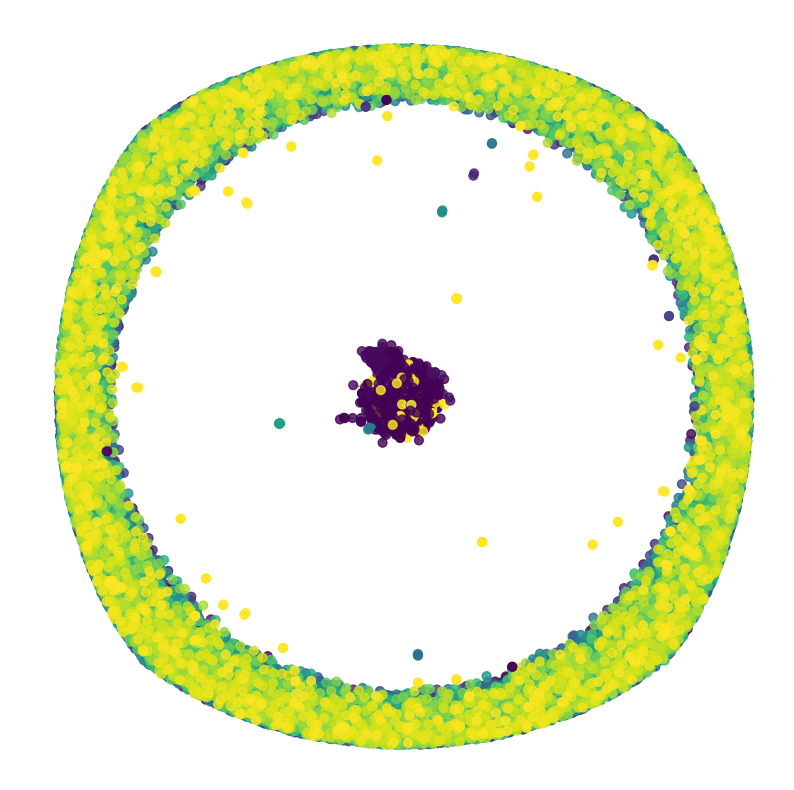

In [87]:
draw_graph(graph=g, seed=42)